# Plotting in Python

[Matplotlib](https://matplotlib.org/) (MPL) is the default choice, with other options including [Seaborn](https://seaborn.pydata.org) for high-level plotting, [Plotly](https://plot.ly/python/) for JS plotting framework, [Bokeh](https://bokeh.org/) for interactive plotting.


## Installation

Matplotlib is included in the [Anaconda](https://www.anaconda.com/products/individual) distribution.

Install it via `conda` in case you got a miniconda distribution that comes without

```bash
conda install matplotlib
```

If you're using `pip` instead of `conda`

```bash
pip install matplotlib
```

## Reference

* [Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html)
* [Scipy Lecture Notes](http://www.scipy-lectures.org/intro/matplotlib/index.html)
* [Numerical Python Course](https://www.python-course.eu/matplotlib.php)
* [Python Graph Gallery](https://python-graph-gallery.com/)
* [Matplotlib official guide](https://matplotlib.org/users/index.html)
* [Matplotlib Tutorial – A Complete Guide to Python Plot w/ Examples](https://www.machinelearningplus.com/plots/matplotlib-tutorial-complete-guide-python-plot-examples)
* [Top 50 matplotlib visualizations ](https://www.machinelearningplus.com/plots/top-50-matplotlib-visualizations-the-master-plots-python/)
* [Matplotlib Tutorial: Learn the basics of Python’s powerful Plotting library](https://towardsdatascience.com/matplotlib-tutorial-learn-basics-of-pythons-powerful-plotting-library-b5d1b8f67596)

**Anatomy of a figure** (from mpl official website)

![](https://matplotlib.org/3.2.1/_images/sphx_glr_anatomy_001.png)

Conventional short names for `matplotlib` and `numpy`:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
# For inline plotting in jupyter notebooks
%matplotlib inline  

## Line plots

Line plots are usually for visualization of 2D data.

e.g. time series (y-t), phase plots (x-y)

```py
plt.plot(xs, ys)
```

See also

* [Line styles](https://matplotlib.org/gallery/lines_bars_and_markers/line_styles_reference.html)
* [Line color and dot styles](https://matplotlib.org/2.1.1/api/_as_gen/matplotlib.pyplot.plot.html)
* [figure()](https://matplotlib.org/3.1.0/api/_as_gen/matplotlib.pyplot.figure.html?highlight=figure#matplotlib.pyplot.figure)

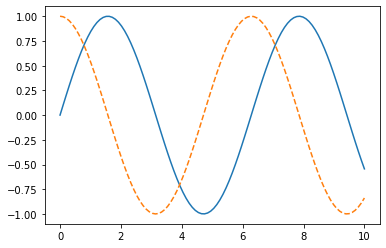

In [2]:
# Data #
x = np.linspace(0, 10, num=100)
y1 = np.sin(x)
y2 = np.cos(x)

# Opens a new figure to be plotted
plt.figure()

# plot(x, y, <MATLAB stylestring>)
plt.plot(x, y1, '-')  
plt.plot(x, y2, '--')

Add more things to the plot.

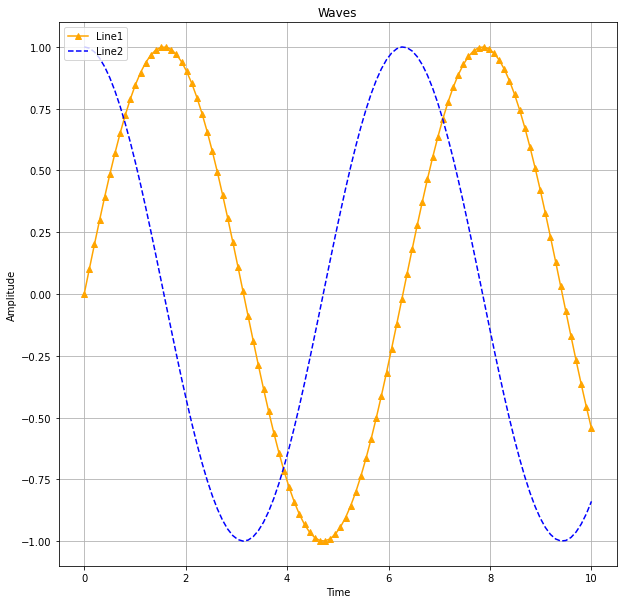

In [3]:
# Let's add some more options

# Set figure (whole picture) size to 10 * 10
plt.figure(figsize = (10, 10))

# Add grid
plt.grid() 

# Title
plt.title("Waves")

# Lables for X & Y axes
plt.xlabel("Time")
plt.ylabel("Amplitude")

# 'o-' does not mean orange line rather than circle dots
# '^' means triangle dots
# line labels are also set
plt.plot(x, y1, '^-', label="Line1", color='orange')  
plt.plot(x, y2, 'b--', label="Line2")

# Show the labels
plt.legend(loc='upper left')

### Line customization

- color:
https://xkcd.com/color/rgb/

- line/marker style:
https://www.labri.fr/perso/nrougier/teaching/matplotlib/#figures-subplots-axes-and-ticks

<div style="display:inline-block;">
    <a href="https://imgur.com/OaaO9GE" ><img src="https://i.imgur.com/OaaO9GE.png" title="source: imgur.com" align="left" width = 42%>
    </a>
    <a href="https://imgur.com/IhUOXv6"><img src="https://i.imgur.com/IhUOXv6.png" title="source: imgur.com" align="right" width = 50%>
    </a>
</div>


## Multiple series

**1 column = 1 series of data**

In [4]:
# Data #
x = np.linspace(0, 10, 100)

# 4 columns of data = 4 series
# y = sin(x + 0.5k * pi); k = 0, 1, 2, 3
y = np.sin(x[:, np.newaxis] + np.pi * np.arange(0, 2, 0.5))
y.shape

(100, 4)

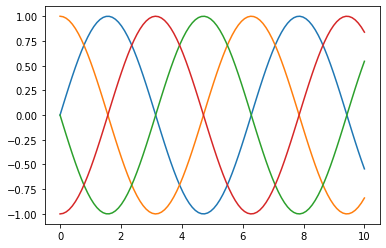

In [5]:
plt.figure()
plt.plot(x, y)

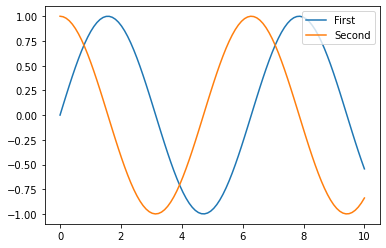

In [6]:
plt.figure()
lines = plt.plot(x, y[:, 0:2])

# Another way to set labels
plt.legend(lines, ['First', 'Second'], loc='upper right')

## Tweaking Axis ticks

* Logarithmic scale

```py
plt.xscale('log')
```

* Hiding ticks. [@stack overflow](https://stackoverflow.com/questions/12998430/remove-xticks-in-a-matplotlib-plot)

```py
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
```

See also: [axes()](https://matplotlib.org/3.1.1/api/axes_api.html)

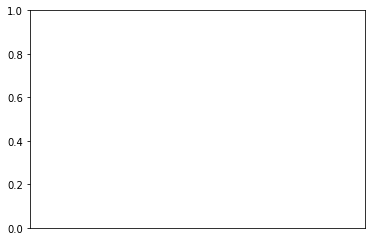

In [7]:
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off

Text(0, 0.5, 'dB')

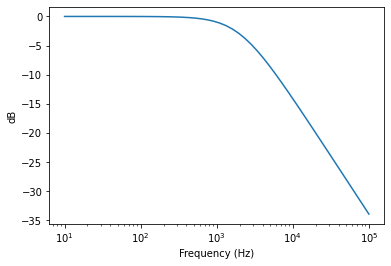

In [8]:
# Bode plot example

# Transfer function
def H(w):
    wc = 4000*np.pi
    return 1.0 / (1.0 + 1j * w / wc)

freq = np.logspace(1,5) # frequencies from 10**1 to 10**5 Hz

plt.figure()
plt.plot(freq, 20*np.log10(abs(H(2*np.pi*freq))))
plt.xscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('dB')

## Multiple subplots

One could use MATLAB-style to define the subplots. 

But the object-oriented way is even better. See [`subplots()`](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.subplots.html).

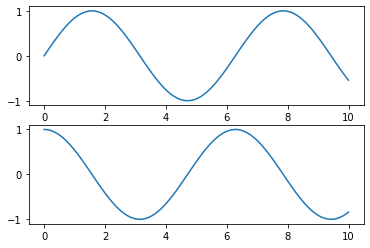

In [9]:
# MATLAB style
# subplot(rows, columns, panel number)
plt.subplot(2, 1, 1)
plt.plot(x, y1)
# create the second panel and set current axis
plt.subplot(2, 1, 2)
plt.plot(x, y2)

Text(0.5, 0.98, 'Common title')

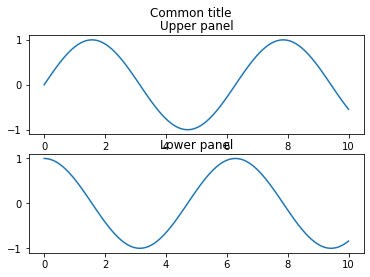

In [10]:
# OO style (recommended)
fig, ax = plt.subplots(2)
# Plot for each axes (an unit in the figure)
ax[0].plot(x, y1)
ax[0].set_title("Upper panel")
ax[1].plot(x, y2)
ax[1].set_title("Lower panel")
# Common title
plt.suptitle("Common title")

## Scatter plots

```py
plt.plot(x, y, 'o')
```

Ref: [Python Data Science Handbook ](https://jakevdp.github.io/PythonDataScienceHandbook/04.02-simple-scatter-plots.html)

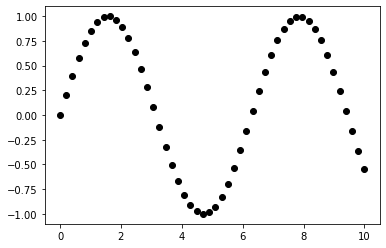

In [11]:
# Using plot() function
plt.figure()
x = np.linspace(0, 10)
y1 = np.sin(x)
plt.plot(x, y1, 'o', color='black')
# Same as plt.scatter(x, y1, marker='o', color='black')

## Color map (cmap) and colorbar()
```py
plt.scatter(x, y, c=colors)
plt.colorbar()
```

See also [colormaps](https://matplotlib.org/3.1.0/tutorials/colors/colormaps.html) and [colorbar](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.colorbar.html)

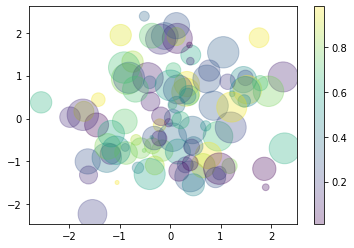

In [12]:
# Data #
rng = np.random.RandomState(0)
x = rng.randn(100)
y = rng.randn(100)
colors = rng.rand(100)
sizes = 1000 * rng.rand(100)

# Plot #
plt.figure()

# cmap for color mapping
plt.scatter(x, y, c=colors, s=sizes, alpha=0.3, cmap='viridis')

# show color scale bar
plt.colorbar()

## Error bar
```py
plt.errorbar(x, y, yerr=dy, fmt='.k')
```

See also: [errorbar](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.errorbar.html)

<ErrorbarContainer object of 3 artists>

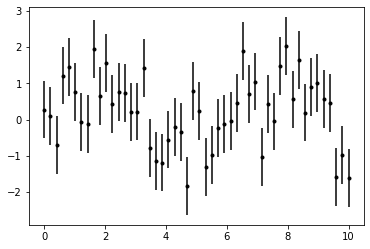

In [13]:
# Data #
x = np.linspace(0, 10, 50)  # Input
dy = 0.8                                  # Uncertainty level
y = np.sin(x) + dy * np.random.randn(50)  # Output with uncertainty

# Plot #
plt.figure()
# xerr or yerr parameter to set error bars
plt.errorbar(x, y, yerr=dy, fmt='.k')

## Contour plots

```py
plt.contour(X, Y, Z)
```

See also [`contour()`](https://matplotlib.org/3.1.0/api/_as_gen/matplotlib.pyplot.contour.html) and [`imshow()`](https://matplotlib.org/3.1.0/api/_as_gen/matplotlib.pyplot.imshow.html?highlight=imshow#matplotlib.pyplot.imshow)

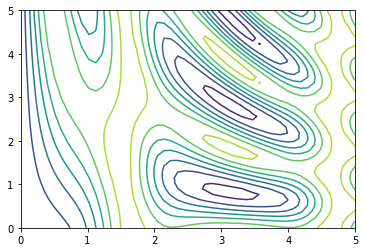

In [14]:
# data #
def f(x, y):
    return np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 40)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# plot #
plt.figure()
plt.contour(X, Y, Z)

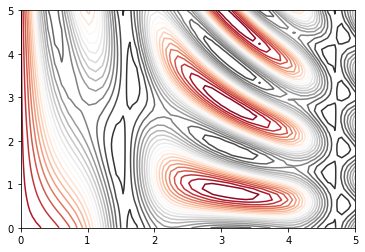

In [15]:
plt.figure()
# Change color map
plt.contour(X, Y, Z, 20, cmap='RdGy')

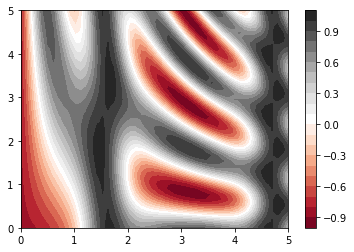

In [16]:
plt.figure()

# contourf() for filled countor plot
plt.contourf(X, Y, Z, 20, cmap='RdGy')
plt.colorbar()

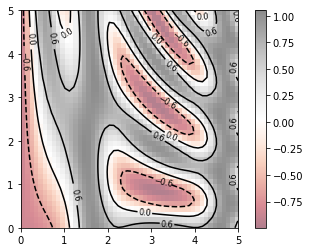

In [17]:
plt.figure()
contours = plt.contour(X, Y, Z, 3, colors='black')

# Add labels of levels in the contour plot
plt.clabel(contours, inline=True, fontsize=8)

# Render image on the plot (faster but lower quality)
plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower', cmap='RdGy', alpha=0.5)

plt.colorbar()

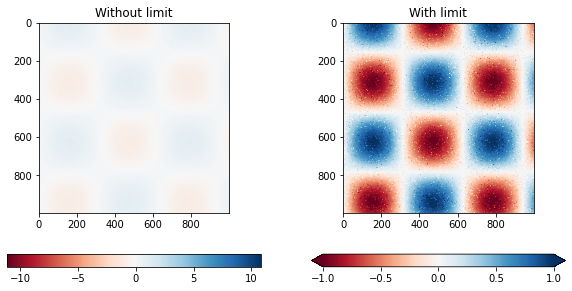

In [18]:
#### set_clim() to set limits on the values in the color bar

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Data #
x = np.linspace(0, 10, 1000)	            # 1000 * 1
I = np.sin(x) * np.cos(x[:, np.newaxis])  # 1000 * 1000
speckles = (np.random.random(I.shape) < 0.01)
I[speckles] = np.random.normal(0, 3, np.count_nonzero(speckles))

# Figure #
fig, axs = plt.subplots(ncols=2, figsize=(10, 5))
# Left subplot
axs[0].set_title('Without limit')
im0 = axs[0].imshow(I, cmap='RdBu')
cb0 = plt.colorbar(im0, ax=axs[0], orientation='horizontal')
# Right subplot
axs[1].set_title('With limit')
im1 = axs[1].imshow(I, cmap='RdBu')
im1.set_clim(-1, 1)
cb1 = plt.colorbar(im1, ax=axs[1], extend='both', orientation='horizontal')

## Plotting vector fields (quiver / streamplot plot)

Source: <https://scipython.com/blog/visualizing-the-earths-magnetic-field/>

More on: [quiver()](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.axes.Axes.quiver.html?highlight=quiver#matplotlib.axes.Axes.quiver), [streamplot()](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.axes.Axes.streamplot.html?highlight=streamplot#matplotlib.axes.Axes.streamplot)

Another example: <https://stackoverflow.com/questions/25342072/computing-and-drawing-vector-fields>

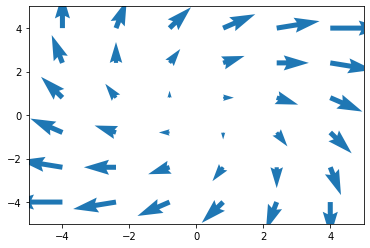

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# make data
x = np.linspace(-4, 4, 6)
y = np.linspace(-4, 4, 6)
X, Y = np.meshgrid(x, y)
U = X + Y
V = Y - X

# plot
fig, ax = plt.subplots()

ax.quiver(X, Y, U, V, color="C0", angles='xy',
          scale_units='xy', scale=5, width=.015)

ax.set(xlim=(-5, 5), ylim=(-5, 5))

plt.show()

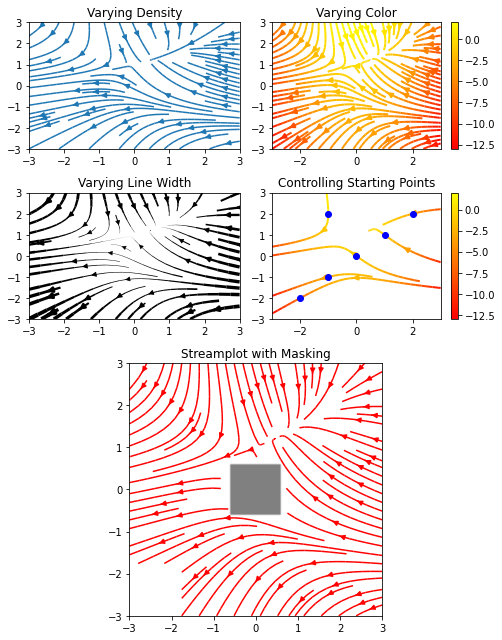

In [20]:
# Streamplot examples
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

w = 3
Y, X = np.mgrid[-w:w:100j, -w:w:100j]
U = -1 - X**2 + Y
V = 1 + X - Y**2
speed = np.sqrt(U**2 + V**2)

fig = plt.figure(figsize=(7, 9))
gs = gridspec.GridSpec(nrows=3, ncols=2, height_ratios=[1, 1, 2])

#  Varying density along a streamline
ax0 = fig.add_subplot(gs[0, 0])
ax0.streamplot(X, Y, U, V, density=[0.5, 1])
ax0.set_title('Varying Density')

# Varying color along a streamline
ax1 = fig.add_subplot(gs[0, 1])
strm = ax1.streamplot(X, Y, U, V, color=U, linewidth=2, cmap='autumn')
fig.colorbar(strm.lines)
ax1.set_title('Varying Color')

#  Varying line width along a streamline
ax2 = fig.add_subplot(gs[1, 0])
lw = 5*speed / speed.max()
ax2.streamplot(X, Y, U, V, density=0.6, color='k', linewidth=lw)
ax2.set_title('Varying Line Width')

# Controlling the starting points of the streamlines
seed_points = np.array([[-2, -1, 0, 1, 2, -1], [-2, -1,  0, 1, 2, 2]])

ax3 = fig.add_subplot(gs[1, 1])
strm = ax3.streamplot(X, Y, U, V, color=U, linewidth=2,
                      cmap='autumn', start_points=seed_points.T)
fig.colorbar(strm.lines)
ax3.set_title('Controlling Starting Points')

# Displaying the starting points with blue symbols.
ax3.plot(seed_points[0], seed_points[1], 'bo')
ax3.set(xlim=(-w, w), ylim=(-w, w))

# Create a mask
mask = np.zeros(U.shape, dtype=bool)
mask[40:60, 40:60] = True
U[:20, :20] = np.nan
U = np.ma.array(U, mask=mask)

ax4 = fig.add_subplot(gs[2:, :])
ax4.streamplot(X, Y, U, V, color='r')
ax4.set_title('Streamplot with Masking')

ax4.imshow(~mask, extent=(-w, w, -w, w), alpha=0.5, cmap='gray', aspect='auto')
ax4.set_aspect('equal')

plt.tight_layout()
plt.show()

### anotations

anotations: https://matplotlib.org/tutorials/text/annotations.html#plotting-guide-annotation

Text(0.5, 0.5, 'fixed arrow')

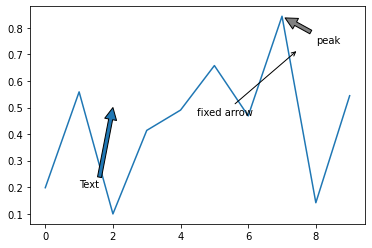

In [21]:
data = np.random.rand(10)
plt.plot(data)
plt.annotate("Text",(2,0.5),(1,0.2),arrowprops= dict())

plt.annotate("peak",
             (np.where(data==data.max())[0][0],data.max()), # where to point
             xycoords='data', 
             xytext=(np.where(data==data.max())[0][0]+1,data.max()-0.1), # where to put text
             arrowprops = dict(facecolor="grey",shrink=0.09)) # arrow property

plt.annotate("fixed arrow",
             (0.8,0.8),xycoords='axes fraction',
             xytext=(0.5,0.5),textcoords='axes fraction',
             arrowprops = dict(arrowstyle="->")
            )

# plt.show()